In [1]:
import os
os.environ["PYTHONWARNING"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

In [4]:
sc.settings.set_figure_params(frameon=False, fontsize=8)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
adata = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()

In [8]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 590 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)


In [9]:
ribosomal_translation = [
    "RPS4Y1", "RPS27L", "RPS26", "RPS21", "RPS20", "RPS17", "RPS10", "RPL10",
    "RPL8", "RPL7L1", "RPL39", "RPL36AL", "RPL36A", "RPL30", "RPL26L1", "RPL22",
    "RPL17", "RPL10L"
]

mitochondrial_translation = [
    "MRPS7", "MRPS23", "MRPS18C", "MRPS16", "MRPS14", "MRPS12", "MRPL9", "MRPL58",
    "MRPL47", "MRPL34", "MRPL3", "MRPL22", "MRPL21", "MRPL18", "MRPL17", "MRPL13",
    "MRPL12"
]

In [10]:
# Filter to genes present in adata_tumour
ribo_present = [g for g in ribosomal_translation if g in adata.var_names]
mito_present = [g for g in mitochondrial_translation if g in adata.var_names]

print(f"Ribosomal genes found: {len(ribo_present)}/{len(ribosomal_translation)}")
print(f"Mitochondrial genes found: {len(mito_present)}/{len(mitochondrial_translation)}")

ribo_missing = set(ribosomal_translation) - set(ribo_present)
mito_missing = set(mitochondrial_translation) - set(mito_present)
if ribo_missing:
    print(f"  Ribosomal missing: {ribo_missing}")
if mito_missing:
    print(f"  Mitochondrial missing: {mito_missing}")

Ribosomal genes found: 18/18
Mitochondrial genes found: 17/17


In [11]:
quiescence = adata.obs["oren_quiescence"].values

# Spearman correlation for each gene
def compute_spearman(gene_list, label):
    results = []
    for gene in gene_list:
        expr = np.asarray(adata[:, gene].X.todense()).flatten() \
            if hasattr(adata.X, "todense") else adata[:, gene].X.flatten()
        rho, pval = spearmanr(expr, quiescence)
        results.append({"gene": gene, "group": label, "rho": rho, "pval": pval})
    return results

results = compute_spearman(ribo_present, "Ribosomal") + compute_spearman(mito_present, "Mitochondrial")
corr_df = pd.DataFrame(results).sort_values("rho")

# FDR correction
_, corr_df["padj"], _, _ = multipletests(corr_df["pval"], method="fdr_bh")

corr_df["sig"] = corr_df["padj"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
corr_df

,gene,group,rho,pval,padj,sig
13,RPL30,Ribosomal,-0.166095,0.000000e+00,0.000000e+00,***
5,RPS17,Ribosomal,-0.115067,1.567541e-250,2.743197e-249,***
8,RPL8,Ribosomal,-0.113740,8.439529e-245,9.846117e-244,***
2,RPS26,Ribosomal,-0.110995,3.718174e-233,3.253402e-232,***
6,RPS10,Ribosomal,-0.094686,5.894932e-170,4.126452e-169,***
34,MRPL12,Mitochondrial,-0.075100,1.762450e-107,8.812249e-107,***
27,MRPL34,Mitochondrial,-0.073362,1.220446e-102,5.339450e-102,***
31,MRPL18,Mitochondrial,-0.061072,1.174568e-71,4.567764e-71,***
21,MRPS16,Mitochondrial,-0.047986,6.716709e-45,2.350848e-44,***
25,MRPL58,Mitochondrial,-0.046596,1.970869e-42,6.270948e-42,***


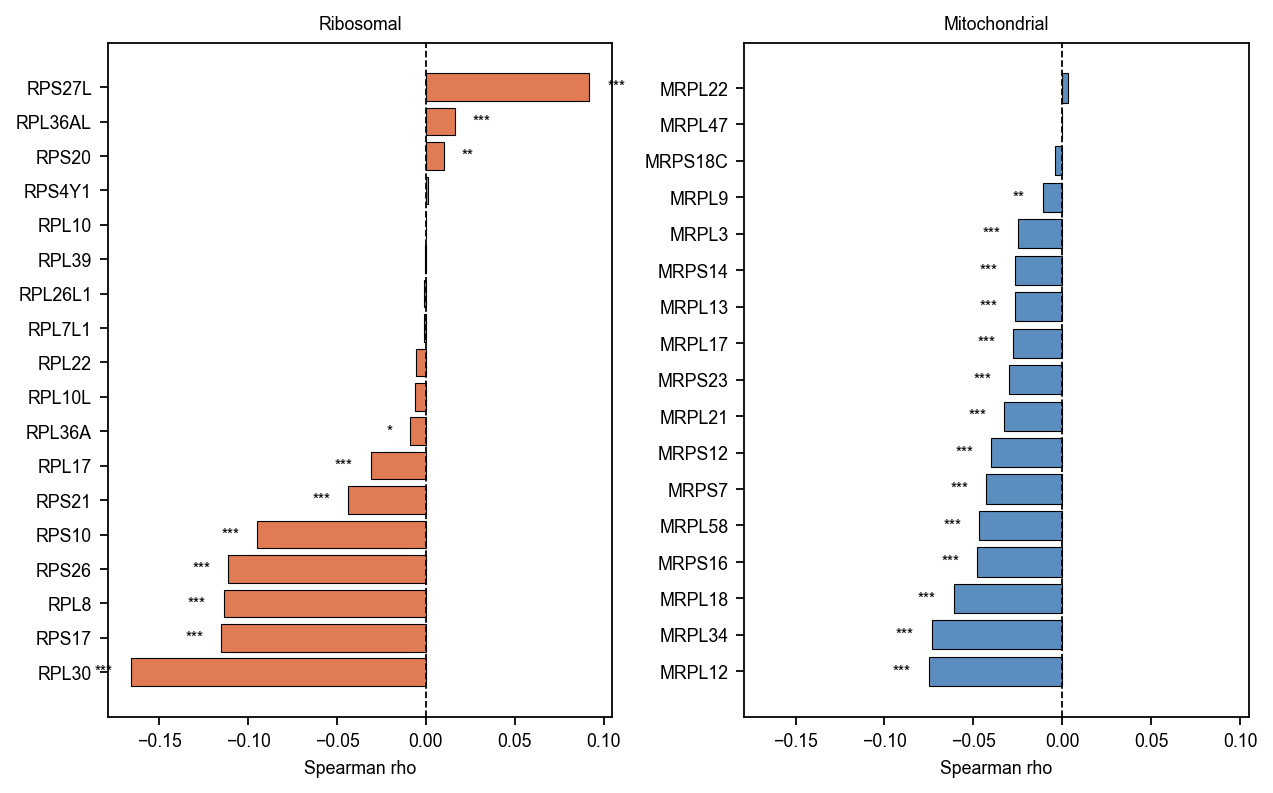

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = {"Ribosomal": "#E07B54", "Mitochondrial": "#5B8DBE"}

# Split data
ribo_df = corr_df[corr_df["group"] == "Ribosomal"].copy()
mito_df = corr_df[corr_df["group"] == "Mitochondrial"].copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True)

# ---- Ribosomal ----
ax = axes[0]
bars = ax.barh(
    range(len(ribo_df)),
    ribo_df["rho"],
    color=colors["Ribosomal"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_yticks(range(len(ribo_df)))
ax.set_yticklabels(ribo_df["gene"], fontsize=8)
ax.set_title("Ribosomal")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for i, (_, row) in enumerate(ribo_df.iterrows()):
    if row["sig"] != "ns":
        x_pos = row["rho"] + (0.01 if row["rho"] >= 0 else -0.01)
        ha = "left" if row["rho"] >= 0 else "right"
        ax.text(x_pos, i, row["sig"], va="center", ha=ha, fontsize=7)

# ---- Mitochondrial ----
ax = axes[1]
bars = ax.barh(
    range(len(mito_df)),
    mito_df["rho"],
    color=colors["Mitochondrial"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_yticks(range(len(mito_df)))
ax.set_yticklabels(mito_df["gene"], fontsize=8)
ax.set_title("Mitochondrial")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for i, (_, row) in enumerate(mito_df.iterrows()):
    if row["sig"] != "ns":
        x_pos = row["rho"] + (0.01 if row["rho"] >= 0 else -0.01)
        ha = "left" if row["rho"] >= 0 else "right"
        ax.text(x_pos, i, row["sig"], va="center", ha=ha, fontsize=7)

# Shared formatting
for ax in axes:
    ax.set_xlabel("Spearman rho")
    ax.grid(False)

plt.tight_layout()
plt.savefig(figure_dir + "ribo_mito_quiescence_spearman.pdf", bbox_inches="tight")
plt.show()